###  MFCC-Chroma Fusion using a Dual-Channel CNN-LSTM Preprocessing Pipeline

##### Import Statements

In [21]:
import numpy as np
import pandas as pd
import os
import librosa as lb
import soundfile as sf
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
import shutil
import matplotlib.pyplot as plt
import zipfile
from collections import defaultdict
import random

from scipy.signal import butter, filtfilt
import librosa as lb
import numpy as np

### 1. Initial Configuration 

##### Defined Parameters

In [ ]:
# Target size per class (train only)
TARGET_COUNT = 500                      
SEG_LEN = 3
SR = 4000

##### Paths

In [23]:
# Where the dataset rests
RAW_DATA_DIR = "./Respiratory_Sound_Database"

ROOT_DIR = "./" 

#Save Directories
SEGMENTS_DIR = "outputs/segmentation_outputs/" 
TRAIN_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/train_segments" 
TEST_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/test_segments" 
VAL_SEGMENTS_AUGMENTED_DIR = "outputs/augmentation_outputs/val_segments" 

In [24]:
shutil.rmtree(os.path.join(ROOT_DIR,"outputs"), ignore_errors=True)
shutil.rmtree("./../dataset", ignore_errors=True)

##### Filters and Normalization

The function `load_audio` essentially loads the different audio clips following a 4000Hz sampling rate and applies butterworth filtering prior to returning the audio file. This function will be used to load the **unsegmented** audio files. 

In [25]:
def butterworth_filter(y, sr, lowcut=50, highcut=1800, order=4):
    nyquist = 0.5 * sr

    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, y)

The function `rms_normalize` will be applied to **each segment** aftey they are created and before they are exported to the save directories defined.

In [26]:
def rms_normalize(y, eps=1e-9, min_rms=1e-3):
    rms = np.sqrt(np.mean(y**2) + eps)
    if rms < min_rms:
        return y  # avoid boosting silence
    return y / rms

##### Augmentation

In [27]:
def augment_noise(y, sr=SR):
    return y + np.random.normal(0, 0.005, len(y))


def augment_pitch(y, sr=SR):
    steps = np.random.uniform(-2, 2)
    return lb.effects.pitch_shift(y=y, sr=sr, n_steps=steps)


def augment_speed(y, sr=SR):
    rate = np.random.uniform(0.95, 1.05)
    y = lb.effects.time_stretch(y=y, rate=rate)

    target_len = 3 * sr
    if len(y) > target_len:
        y = y[:target_len]
    else:
        y = np.pad(y, (0, target_len - len(y)))

    return y


def augment_gain(y, sr=SR):
    return y * np.random.uniform(0.8, 1.2)


def augment_time_shift(y, sr=SR):
    shift = int(np.random.uniform(-0.1, 0.1) * len(y))
    return np.roll(y, shift)


def augment_freq_mask(y, sr=SR):
    S = np.fft.rfft(y)
    mask_size = int(np.random.uniform(0.05, 0.15) * len(S))
    start = np.random.randint(0, len(S) - mask_size)
    S[start:start + mask_size] = 0
    return np.fft.irfft(S, n=len(y))


# Python list containing all of the augmentation methods
AUGS = [
    augment_noise,
    augment_pitch,
    augment_speed,
    augment_gain,
    augment_time_shift,
    augment_freq_mask
]

### 2. Creating the Reference Data Frame

In [28]:
# Extracts relevant information from the file name
def get_filename_info(file):
    return file.split("_")

In [ ]:
def read_icbhi_metadata(data_dir):

    audio_dir = os.path.join(data_dir, "audio_and_txt_files") # Where all of the audio files are stored in the ICBHI dataset
    diagnosis_path = os.path.join(data_dir, "patient_diagnosis.csv") # The CSV file that maps the PID to a disease within the dataset

    # Read patient diagnoses
    patient_df = pd.read_csv(diagnosis_path, names=["pid", "disease"])
    patient_df.pid = patient_df.pid.astype(int) # DF that holds PID and associated Disease

    # Read all annotation txt files
    txt_files = sorted([f for f in os.listdir(audio_dir) if f.endswith(".txt")]) # All of the annotiation files associated with the recordings

    rows = []

    # Iterate through all of the audio file annotations and create a datafram that stores all of the data. 
    # It gets the start, end, crackles, and wheezes annotations from the .txt files 
    #   and the PID from the filename itself and the actual filename too.
    for txt in txt_files:
        file = txt.replace(".txt", "")
        metadata = pd.read_csv(
            os.path.join(audio_dir, txt),
            sep="\t",
            names=["start", "end", "crackles", "wheezes"]
        )
        pid = int(get_filename_info(file)[0]) #  Gets only the first part of the filename which is the PID

        metadata["filename"] = file
        metadata["pid"] = pid

        rows.append(metadata)

    # Combine all annotations
    df = pd.concat(rows)

    # We carry out a merge of the two dataframes using the patient ID so we can have one giant dataframe with all of the necessary information
    df = df.merge(patient_df, on="pid")


    print("The total number of patients within the dataset is exactly", patient_df['pid'].count())
    print("The total number of segments of data within the entire dataset amounts to", df['pid'].count())
    print("After carrying out the join, the total number of segments of data within the entire dataset amounts to", df['pid'].count())


    # We drop disease classes with fewer than 3 unique patients
    counts = df.groupby('disease')['pid'].nunique()
    rare_classes = counts[counts < 3].index.tolist()
    if rare_classes:
        print(f"\nDropping the following rare disease classes with < 3 patients: {rare_classes}")
        df_dropped = df[~df['disease'].isin(rare_classes)].copy()
    else: 
        df_dropped = df.copy()

    
    print("\nThese rare classes have the following number of patients:")
    print(counts[rare_classes])

    print("\nThe Total number of segments that are found among these rare classes amounts to:", df[df['disease'].isin(rare_classes)]['pid'].count())

    print("\nThen, the revised total number of segments after dropping the segments of these rare classes amounts to", df_dropped['pid'].count())

    # We reset the index because of the entries we dropped. We don't want the jumps evident in the dataset because they become confusing later on
    df_dropped = df_dropped.reset_index(drop=True)
    return df_dropped


df = read_icbhi_metadata(RAW_DATA_DIR)
os.makedirs("outputs", exist_ok=True)
df.to_csv("outputs/df_with_rare_classes_dropped.csv")

### 3. Patient-Level Constrained Stratified Split


This script performs a proper patient-level split for lung sound datasets.

Properties:
- No patient appears in more than one subset
- Guarantees each disease class appears in train, test, unseen (if >= 3 patients)
- 90% development / 10% unseen
- 80/20 train/test inside development
- Reproducible with random seed

Input CSV format (one row per segment or file):
pid, disease, filepath,...

Output:
train_pids.txt
test_pids.txt
val_pids.txt


In [30]:
# CONFIGURATION
UNSEEN_RATIO = 0.10             # 10%
TEST_RATIO_WITHIN_DEV = 0.20    # 20% of development


def constrained_patient_split(pid_df, seed=42):
    rng = np.random.default_rng(seed)

    counts = pid_df.groupby("disease")["pid"].nunique()
    valid_classes = counts.index


    pid_df = pid_df[pid_df["disease"].isin(valid_classes)].copy()
    print("Classes kept:", list(valid_classes))
    print("Classes removed:", list(counts[counts < 3].index))

    # Group the different PIDs by class
    class_groups = {
        cls: pid_df[pid_df["disease"] == cls]["pid"].unique()
        for cls in valid_classes
    }

    train_pool = []
    test_pids = set()
    unseen_pids = set()

    # Ensure that there is a minimum 1 PID per class per subset
    for cls, pids in class_groups.items():
        pids = list(pids)
        rng.shuffle(pids)

        unseen_pids.add(pids[0])
        test_pids.add(pids[1])

        train_pool.extend(pids[2:])

    # Compute target sizes
    all_pids = pid_df["pid"].unique()
    total = len(all_pids)

    target_unseen = int(round(total * UNSEEN_RATIO))

    rng.shuffle(train_pool)

    # Fill unseen
    while len(unseen_pids) < target_unseen and train_pool:
        unseen_pids.add(train_pool.pop())

    # Development pool
    dev_pool = [pid for pid in all_pids if pid not in unseen_pids]

    target_test = int(round(len(dev_pool) * TEST_RATIO_WITHIN_DEV))

    remaining = [pid for pid in dev_pool if pid not in test_pids]
    rng.shuffle(remaining)

    # Fill test
    while len(test_pids) < target_test and remaining:
        test_pids.add(remaining.pop())

    # Rest → train
    train_pids = [pid for pid in dev_pool if pid not in test_pids]

    train_pids  = sorted(map(int, train_pids))
    test_pids   = sorted(map(int, test_pids))
    unseen_pids = sorted(map(int, unseen_pids))

    train_df = pid_df[pid_df['pid'].isin(train_pids)]
    test_df = pid_df[pid_df['pid'].isin(test_pids)]
    val_df = pid_df[pid_df['pid'].isin(unseen_pids)]

    #Outputs only for validation purposes
    os.makedirs("outputs/constrained_patient_split_outputs", exist_ok=True)
    train_df.to_csv("outputs/constrained_patient_split_outputs/train_df_after_split.csv")
    test_df.to_csv("outputs/constrained_patient_split_outputs/test_df_after_split.csv")
    val_df.to_csv("outputs/constrained_patient_split_outputs/val_df_after_split.csv")

    return train_df, test_df, val_df

train_strat, test_strat, val_strat = constrained_patient_split(df)

Classes kept: ['Bronchiectasis', 'Bronchiolitis', 'COPD', 'Healthy', 'Pneumonia', 'URTI']
Classes removed: []


In [31]:
print("PID per disease class per dataset")
print("----------------------------------------------------- TRAIN -----------------------------------------------------")
train_pid_per_disease = train_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in train_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

print("----------------------------------------------------- TEST -----------------------------------------------------")
test_pid_per_disease = test_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in test_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

print("----------------------------------------------------- VALIDATION -----------------------------------------------------")
val_pid_per_disease = val_strat.groupby("disease")["pid"].unique()
for disease, patient_ids in val_pid_per_disease.items():
    print(f"{disease}: {patient_ids}\n\n")

PID per disease class per dataset
----------------------------------------------------- TRAIN -----------------------------------------------------
Bronchiectasis: [111 116 196 201 215]


Bronchiolitis: [149 161 173 216]


COPD: [104 106 107 109 110 112 114 117 118 120 124 128 130 132 133 134 139 141
 142 145 147 151 154 155 156 158 160 162 166 172 174 175 176 178 180 181
 185 186 189 193 198 200 203 205 211 212 213 221 223]


Healthy: [121 125 126 136 143 153 159 171 179 183 184 187 194 202 208 217 224]


Pneumonia: [122 140 191]


URTI: [101 105 129 131 137 148 150 164 165 197 210]


----------------------------------------------------- TEST -----------------------------------------------------
Bronchiectasis: [168]


Bronchiolitis: [206]


COPD: [113 138 157 163 170 177 192 195 204 207 220]


Healthy: [123 127 144 152 182 214]


Pneumonia: [219 226]


URTI: [119]


----------------------------------------------------- VALIDATION -----------------------------------------------------


### 4. Segmentation

**Naming Convention**

The file format that is followed here looks like this:
    101_1b1_Al_sc_Meditron_r-0_s-0.wav

The r-value pertains to the row_index as seen in the cheat_sheet.csv file which was generated earlier.  

To understand why the s-0  is necessary we first take a look at how the data looks per row.

| INDEX | START | END | CRACKLES | WHEEZES | FILENAME | PID | DISEASE |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 0 | 0.036 | 0.579 | 0 | 0 | 101_1b1_Al_sc_Meditron | 101 | URTI |
| 0 | 0.579 | 4.579 | 0 | 0 | 101_1b1_Al_sc_Meditron | 101 | URTI |

Under the first entry we find that the relevant region is only spans 0.543 seconds which is not a problem. But under the second we see that the relevant region spans 4 seconds which is greater than the 3 second segments we intend to follow. As such, the segment will be seperated into n different sub-segments whose unique identifier will be the s-0 keys.

The function `load_audio` essentially loads the different audio clips following a 4000Hz sampling rate and applies butterworth filtering prior to returning the audio file. This function will be used to load the **unsegmented** audio files. 

In [32]:
def load_audio(file_path, sr=SR): # Loads the audio file following the global parameter SAMPLING RATE
    y, sr = lb.load(file_path, sr=sr)
    y = y.astype(np.float32)

    # Butterworth bandpass filter
    y = butterworth_filter(
        y,
        sr,
        lowcut=50,     # remove heart sounds & DC
        highcut=1800,  # remove high-frequency noise
        order=4
    )

    return np.clip(y, -1, 1), sr

In [33]:
import math

def extract_segments(df, data_dir, save_dir, segment_folder):
    audio_dir = os.path.join(data_dir, "audio_and_txt_files")
    seg_folder = os.path.join(save_dir, segment_folder)

    shutil.rmtree(seg_folder, ignore_errors=True)
    os.makedirs(seg_folder)

    segment_list = []

    HOP_LEN = 1  # seconds
    hop_samples = HOP_LEN * SR
    seg_samples = SEG_LEN * SR  # window length in samples

    for row_idx, row in tqdm(df.iterrows(), total=len(df)):
        file = row["filename"]
        start = row["start"]
        end = row["end"]

        wav_path = os.path.join(audio_dir, file + ".wav")
        y, sr = load_audio(wav_path)

        s = int(start * SR)
        e = int(end * SR)
        s = max(0, min(s, len(y)))
        e = max(0, min(e, len(y)))

        if e <= s:
            print(f"Invalid segment window: {file}, start: {start}, end: {end}")
            continue

        relevant_region = y[s:e]
        region_length = len(relevant_region)

        # Always start at 0, then step by hop_samples
        start_idx = 0
        i = 0
        while start_idx < region_length:
            end_idx = start_idx + seg_samples

            seg = relevant_region[start_idx:end_idx]

            # Pad if shorter than window
            if len(seg) < seg_samples:
                seg = np.pad(seg, (0, seg_samples - len(seg)), mode="constant")

            seg = rms_normalize(seg)

            seg_name = f"{file}_r-{row_idx}_s-{i}.wav"
            seg_path = os.path.join(seg_folder, seg_name)
            sf.write(seg_path, seg, SR)

            segment_list.append({
                "og_file": file,
                "segment_file": seg_name,
                "pid": row["pid"],
                "disease": row["disease"],
                "start": start + (start_idx / SR),
                "end": start + (start_idx / SR) + SEG_LEN,
            })

            i += 1
            start_idx += hop_samples  # move to next hop

    return pd.DataFrame(segment_list)


train_segments = extract_segments(train_strat, RAW_DATA_DIR, SEGMENTS_DIR, "train_segments") 
test_segments = extract_segments(test_strat, RAW_DATA_DIR, SEGMENTS_DIR, "test_segments") 
val_segments = extract_segments(val_strat, RAW_DATA_DIR, SEGMENTS_DIR, "val_segments") 

os.makedirs("outputs/segmentation_outputs", exist_ok=True) 
train_segments.to_csv("outputs/segmentation_outputs/train_segments.csv") 
test_segments.to_csv("outputs/segmentation_outputs/test_segments.csv") 
val_segments.to_csv("outputs/segmentation_outputs/val_segments.csv") 

#Outputs only for validation purposes 
print("\nTrain segments count: ", train_segments['pid'].count()) 
print("\nTest segments count: ", test_segments['pid'].count()) 
print("\nVal segments count: ", val_segments['pid'].count())

100%|██████████| 501/501 [00:05<00:00, 86.94it/s] 


Train segments count:  16667

Test segments count:  3741

Val segments count:  1659


In [34]:
#print(train_segments)



#train_pid_per_disease = train_strat.groupby("disease")["pid"].unique() 

    
#train_pid_per_disease = train_strat.groupby("disease")["pid"]
#print(train_pid_per_disease)
# for disease, patient_ids in train_pid_per_disease.items():
#     print(f"{disease}: {patient_ids}\n\n")

# print("----------------------------------------------------- TEST -----------------------------------------------------")
# test_pid_per_disease = test_strat.groupby("disease")["pid"].unique()
# for disease, patient_ids in test_pid_per_disease.items():
#     print(f"{disease}: {patient_ids}\n\n")

# print("----------------------------------------------------- VALIDATION -----------------------------------------------------")
# val_pid_per_disease = val_strat.groupby("disease")["pid"].unique()
# for disease, patient_ids in val_pid_per_disease.items():
#     print(f"{disease}: {patient_ids}\n\n")

### 5. Undersampling and Augmentation. 

**Training Class Only.**

First, we graph the number of segments per disease class to verify how much we have, how much we need to undersample, and how much we need to augment.

##### Segment Distribution

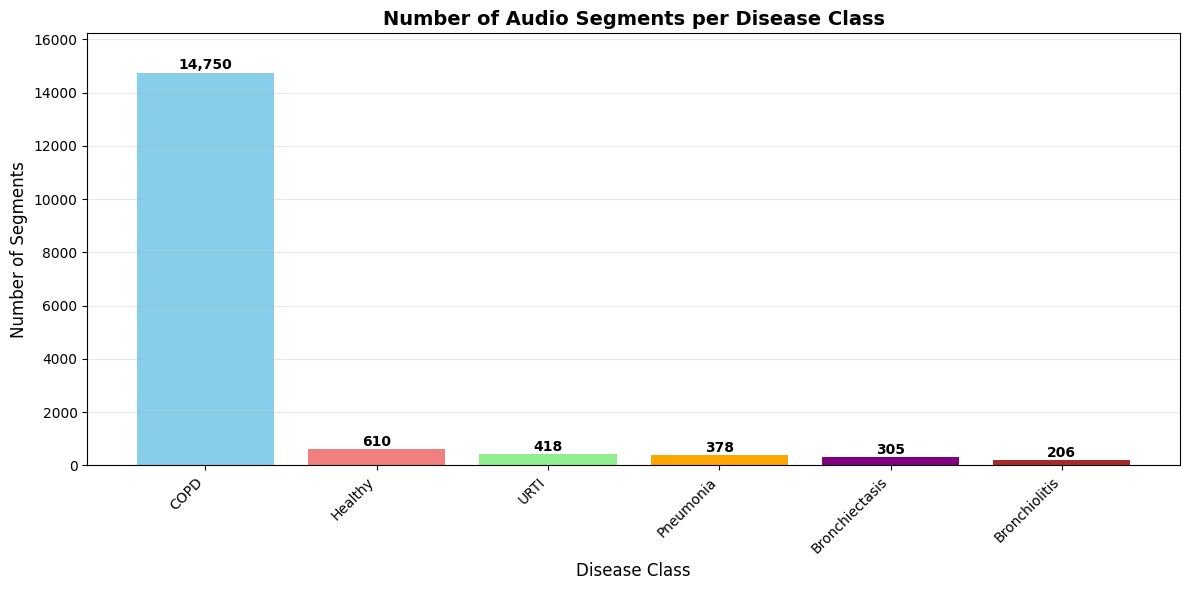

Segment counts per disease:
disease
COPD              14750
Healthy             610
URTI                418
Pneumonia           378
Bronchiectasis      305
Bronchiolitis       206
Name: count, dtype: int64


In [35]:
# Read segments data
seg_df = pd.read_csv('outputs/segmentation_outputs/train_segments.csv')

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

In [36]:
AUGS_PER_CLASS = {
    "Bronchiolitis": 6.5,
    "Bronchiectasis": 4,
    "Pneumonia": 3,
    "URTI": 2.6,
    "Healthy": 1.5,
    "COPD":0
}

##### Function

In [37]:

# segments_per_file = train_segments.groupby(["disease", "pid", "og_file"]).size()

# print(segments_per_file)
# segments_per_file.to_csv("./outputs/distribution.csv")

In [38]:
def augment_training_set(seg_df, source_dir, save_dir, seed=42):
    rng = random.Random(seed)

    updated_records = []

    shutil.rmtree(save_dir, ignore_errors=True)
    os.makedirs(save_dir)

    for disease, group in seg_df.groupby("disease"):

        print("Processing disease:", disease)

        # -----------------------------
        # Undersample COPD
        # -----------------------------
        if disease == "COPD" and len(group) > 1550:
            group = group.sample(n=1550, random_state=seed)

        originals = group["segment_file"].tolist()
        pids = group["pid"].tolist()
        files_with_pid = list(zip(originals, pids))

        # -----------------------------
        # number of augmentations
        # -----------------------------
        aug_factor = AUGS_PER_CLASS[disease]
        base = int(math.floor(aug_factor))
        frac = aug_factor - base

        for file, pid in files_with_pid:

            base_file = os.path.basename(file)
            src_path = os.path.join(source_dir, base_file)

            if not os.path.exists(src_path):
                raise FileNotFoundError(f"Original file missing: {src_path}")

            # -----------------------------
            # Copy original segment
            # -----------------------------
            dest_path = os.path.join(save_dir, base_file)
            shutil.copy(src_path, dest_path)

            updated_records.append({
                "segment_file": base_file,
                "pid": pid,
                "disease": disease,
            })

            # -----------------------------
            # Load audio once
            # -----------------------------
            y, sr = lb.load(src_path, sr=SR)

            # -----------------------------
            # Determine number of augmentations
            # -----------------------------
            n_aug = base
            if rng.random() < frac:
                n_aug += 1

            # -----------------------------
            # Choose augmentations randomly
            # -----------------------------
            chosen_augs = rng.choices(AUGS, k=n_aug)

            for i, aug_fn in enumerate(chosen_augs):

                y_aug = aug_fn(y, sr)

                aug_name = aug_fn.__name__.replace("augment_", "")
                save_name = f"{os.path.splitext(base_file)[0]}_{aug_name}_{i}.wav"

                save_path = os.path.join(save_dir, save_name)
                sf.write(save_path, y_aug, sr)

                updated_records.append({
                    "segment_file": save_name,
                    "pid": pid,
                    "disease": disease,
                })

    df = pd.DataFrame(updated_records)

    df.to_csv("outputs/augmentation_outputs/train_segments.csv", index=False)

    return df

train_augmented = augment_training_set(
    train_segments, os.path.join(ROOT_DIR, SEGMENTS_DIR, "train_segments"), 
    os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR), 
)

Processing disease: Bronchiectasis
Processing disease: Bronchiolitis
Processing disease: COPD
Processing disease: Healthy
Processing disease: Pneumonia
Processing disease: URTI


##### Augmented Segment Distribution

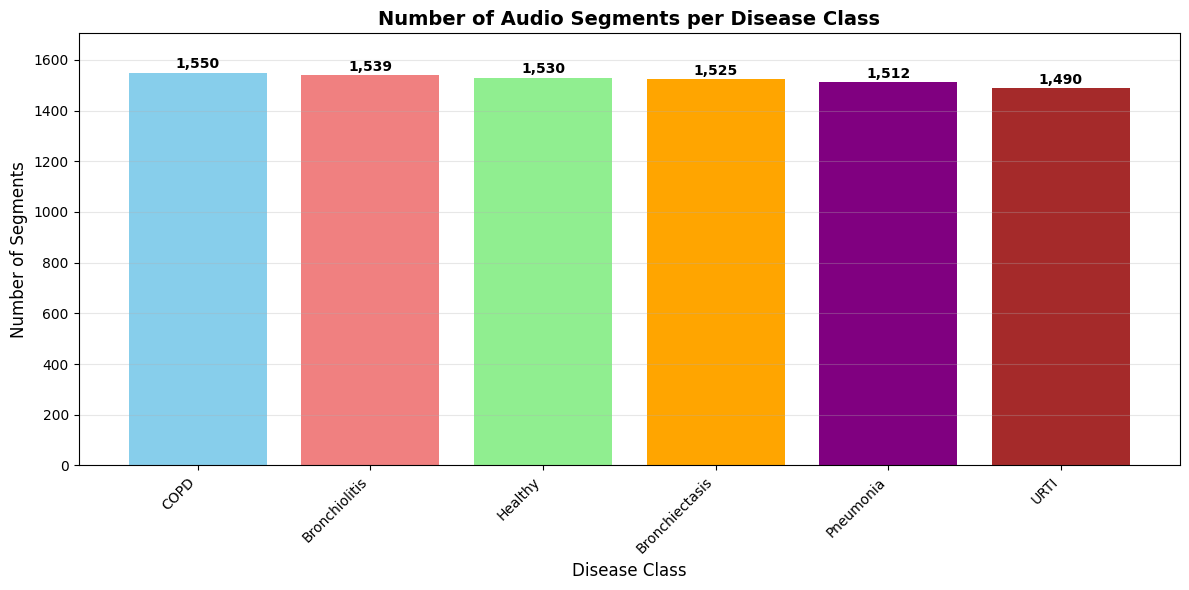

Segment counts per disease:
disease
COPD              1550
Bronchiolitis     1539
Healthy           1530
Bronchiectasis    1525
Pneumonia         1512
URTI              1490
Name: count, dtype: int64


In [39]:
# Read segments data
seg_df = pd.read_csv('outputs/augmentation_outputs/train_segments.csv')

# Count segments per disease
disease_counts = seg_df['disease'].value_counts()

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(disease_counts.index, disease_counts.values, 
               color=['skyblue', 'lightcoral', 'lightgreen', 'orange', 'purple', 'brown', 'gray'])

# Add value labels on bars
for bar, count in zip(bars, disease_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Number of Audio Segments per Disease Class', fontsize=14, fontweight='bold')
plt.xlabel('Disease Class', fontsize=12)
plt.ylabel('Number of Segments', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add some padding to top for labels
plt.ylim(0, disease_counts.max() * 1.1)

plt.tight_layout()
plt.show()

# Print the counts
print("Segment counts per disease:")
print(disease_counts)

In [40]:
shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "test_segments"),
                "../dataset/test-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/test_segments.csv"),
                "../dataset/test_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, SEGMENTS_DIR, "val_segments"),
                "../dataset/val-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/segmentation_outputs/val_segments.csv"),
                "../dataset/val_segments.csv")



shutil.copytree(os.path.join(ROOT_DIR, TRAIN_SEGMENTS_AUGMENTED_DIR),
                "../dataset/train-segments")

shutil.copy(os.path.join(ROOT_DIR, "outputs/augmentation_outputs/train_segments.csv"),
                "../dataset/train_segments.csv")

'../dataset/train_segments.csv'